# 1
- pure comp: molecular
- kij: molecular
- melting: molecular

In [1]:
using Pkg, Revise
using Clapeyron, PyCall
import PyPlot; const plt = PyPlot
import DataFrames

In [28]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter1 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
alanine_held,89.09,5.4647,2.5222,287.59,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter1 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,alanine_held,-0.0612
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter1 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
alanine_held,H,alanine_held,e,3176.6,0.0819 
water,H,alanine_held,e,2801.135,0.060625
water,e,alanine_held,H,2801.135,0.060625
"""
components = ["water", "alanine_held"]
model1 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter1, unlike_parameter1, assoc_parameter1])

println(model1.fluid.params.epsilon.values)
println(model1.fluid.params.sigma.values)
println("======================")
println(model1.fluid.params.epsilon_assoc.values)
println(model1.fluid.params.bondvol.values)
println("kij = ", (1  - ((model1.fluid.params.epsilon.values[2])/(sqrt(model1.fluid.params.epsilon.values[1] * model1.fluid.params.epsilon.values[4])))))
println("Hfus = ", model1.solid.params.Hfus[2])
println("Tm = ", model1.solid.params.Tm[2])

[353.94 338.57037534269443; 338.57037534269443 287.59]
[2.8014570000000003e-10 2.6618285000000003e-10; 2.6618285000000003e-10 2.5222000000000003e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 2801.135, 2801.135, 3176.6]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.060625, 0.060625, 0.0819]
kij = -0.06119999999999992
Hfus = 21148.32
Tm = 692.4



=== HASIL PERHITUNGAN MODEL ===
100×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0            0.0269984
   2 │      274.267          0.0303593
   3 │      278.533          0.033917
   4 │      282.8            0.0376586
   5 │      287.067          0.0415708
   6 │      291.333          0.0456401
   7 │      295.6            0.049854
   8 │      299.867          0.0542006
   9 │      304.133          0.0586689
  10 │      308.4            0.0632495
  11 │      312.667          0.0679339
  12 │      316.933          0.0727148
  13 │      321.2            0.077586
  14 │      325.467          0.0825425
  15 │      329.733          0.0875801
  16 │      334.0            0.0926953
  17 │      338.267          0.0978855
  18 │      342.533          0.103149
  19 │      346.8            0.108483
  20 │      351.067          0.113889
  21 │      355.333          0.119364
  22 │      359.6  

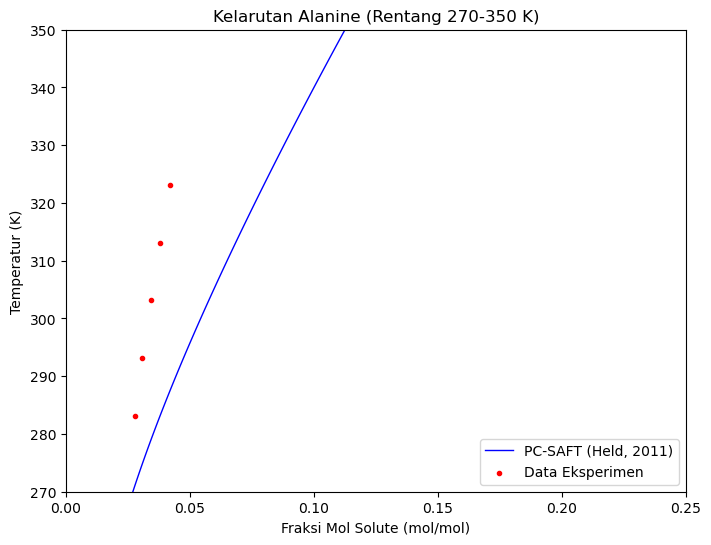

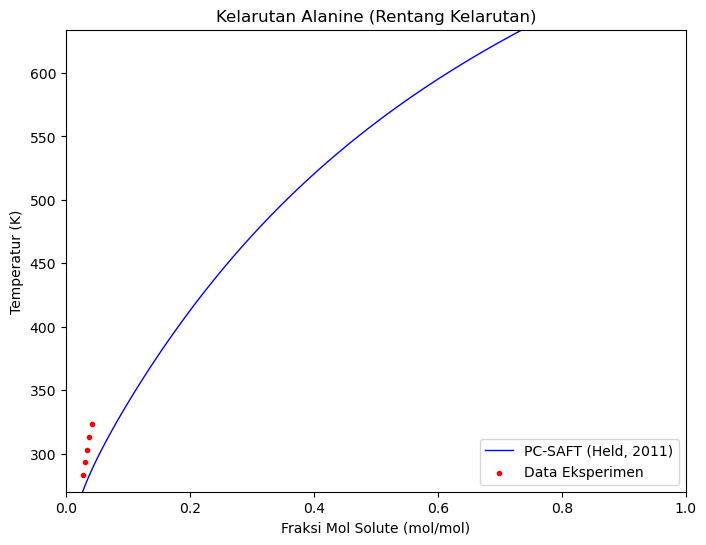

In [29]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_alanine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["alanine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Alanine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_T_alanine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model1.solid.params.Tm[2], 100)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["alanine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Alanine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, 634.138)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_x_alanine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [11]:
using CSV, DataFrames, Printf

function solubility_gclow(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["alanine_gclow"])[2]
    return x2
end

function solubility_gcmid(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["alanine_gcmid"])[2]
    return x2
end

function solubility_gcup(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["alanine_gcup"])[2]
    return x2
end

function solubility_held(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["alanine_held"])[2]
    return x2
end

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [12]:
aard_p   = calculate_AAD(model1, "sol_alanine.csv", solubility_held)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.037973      36.2369 
293.1500    0.030824      0.047417      53.8327 
303.1500    0.034189      0.057629      68.5596 
313.1500    0.037970      0.068471      80.3285 
323.1500    0.042015      0.079841      90.0298 
AARD = 65.7975%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


65.79748914435626

# 2
- pure comp: GC
- kij: GC
- melting: GC

In [30]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter2 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
alanine_gclow,89.09,6.26356,2.463455,264.4748,2,2
alanine_gcmid,89.09,6.26356,2.463455,264.4748,2,2
alanine_gcup,89.09,6.26356,2.463455,264.4748,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter2 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,alanine_gclow,0.1263
water,alanine_gcmid,0.1263
water,alanine_gcup,0.1263
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter2 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
alanine_gclow,H,alanine_gclow,e,3150.875718,0.102188
alanine_gcmid,H,alanine_gcmid,e,3150.875718,0.102188 
alanine_gcup,H,alanine_gcup,e,3150.875718,0.102188 
water,H,alanine_gclow,e,2788.273,0.067393
water,e,alanine_gclow,H,2788.273,0.067393
water,H,alanine_gcmid,e,2788.273,0.067393
water,e,alanine_gcmid,H,2788.273,0.067393
water,H,alanine_gcup,e,2788.273,0.067393
water,e,alanine_gcup,H,2788.273,0.067393
"""
components_low = ["water", "alanine_gclow"]
components_mid = ["water", "alanine_gcmid"]
components_up = ["water", "alanine_gcup"]

model2_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])


println("low bound")
println("Hfus = ", model2_low.solid.params.Hfus[2])
println("Tm = ", model2_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model2_mid.solid.params.Hfus[2])
println("Tm = ", model2_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model2_up.solid.params.Hfus[2])
println("Tm = ", model2_up.solid.params.Tm[2])

low bound
Hfus = 19111.8
Tm = 534.7097
mid bound
Hfus = 22861.0
Tm = 580.58
up bound
Hfus = 26610.2
Tm = 626.4406



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low          X_Mid        X_Up        
     │ Float64       Float64        Float64      Float64     
─────┼───────────────────────────────────────────────────────
   1 │      270.0      9.96326e-8   2.90329e-8   7.93632e-9
   2 │      272.674    1.2664e-7    3.75121e-8   1.04235e-8
   3 │      275.348    1.60208e-7   4.82233e-8   1.36167e-8
   4 │      278.022    2.01745e-7   6.16899e-8   1.76957e-8
   5 │      280.695    2.52922e-7   7.85428e-8   2.28808e-8
   6 │      283.369    3.15715e-7   9.95396e-8   2.94403e-8
   7 │      286.043    3.92449e-7   1.25586e-7   3.77005e-8
   8 │      288.717    4.85853e-7   1.57762e-7   4.80559e-8
   9 │      291.391    5.99118e-7   1.97346e-7   6.09814e-8
  10 │      294.065    7.35961e-7   2.45855e-7   7.70471e-8
  11 │      296.738    9.00701e-7   3.05071e-7   9.69342e-8
  12 │      299.412    1.09834e-6   3.77089e-7   1.21454e-7
  13 │      302.086    1.33464e-6   4.6436e-7

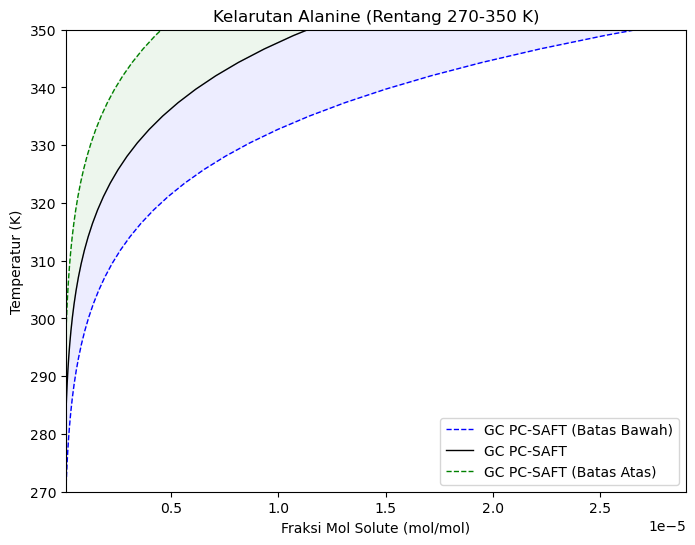

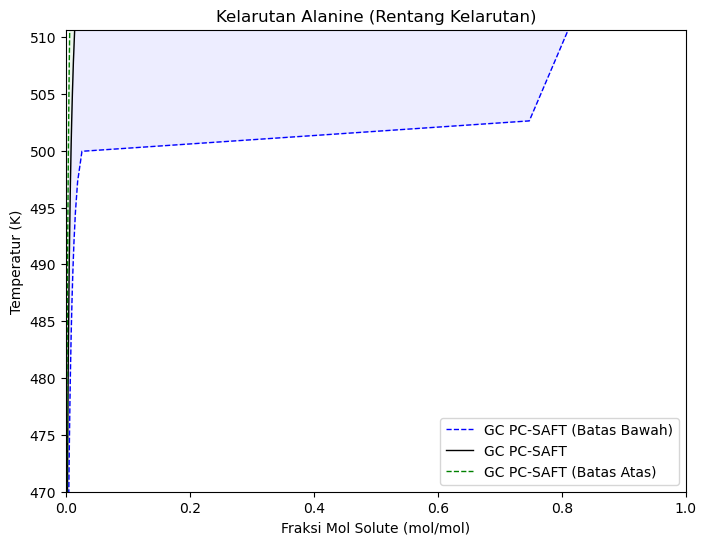

In [32]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_alanine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 500., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["alanine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["alanine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["alanine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Alanine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(9.9e-8, 2.9e-5)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_T_alanine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end


function plot_x(df)
    T = LinRange(270., model2_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["alanine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["alanine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["alanine_gcup"])[2]
    end


    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Alanine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(470.0, 510.645)
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_x_alanine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [22]:
aard_p   = calculate_AAD(model2_low, "sol_alanine.csv", solubility_gclow)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.000000      99.9989 
293.1500    0.030824      0.000001      99.9978 
303.1500    0.034189      0.000001      99.9958 
313.1500    0.037970      0.000003      99.9924 
323.1500    0.042015      0.000006      99.9868 
AARD = 99.9943%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99433324393155

In [23]:
aard_p   = calculate_AAD(model2_mid, "sol_alanine.csv", solubility_gcmid)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.000000      99.9996 
293.1500    0.030824      0.000000      99.9993 
303.1500    0.034189      0.000001      99.9985 
313.1500    0.037970      0.000001      99.9972 
323.1500    0.042015      0.000002      99.9949 
AARD = 99.9979%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99791899904093

In [24]:
aard_p   = calculate_AAD(model2_up, "sol_alanine.csv", solubility_gcup)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.000000      99.9999 
293.1500    0.030824      0.000000      99.9998 
303.1500    0.034189      0.000000      99.9995 
313.1500    0.037970      0.000000      99.9990 
323.1500    0.042015      0.000001      99.9982 
AARD = 99.9993%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99928104851627

# 3
- pure comp: GC
- kij: GC
- melting: molecular

In [33]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter3 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
alanine_held,89.09,6.26356,2.463455,264.4748,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter3 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,alanine_held,0.1263
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter3 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
alanine_held,H,alanine_held,e,3150.875718,0.102188
water,H,alanine_held,e,2788.273,0.067393
water,e,alanine_held,H,2788.273,0.067393
"""
components = ["water", "alanine_held"]
model3 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter3, unlike_parameter3, assoc_parameter3])

println(model3.fluid.params.epsilon.values)
println(model3.fluid.params.sigma.values)
println("======================")
println(model3.fluid.params.epsilon_assoc.values)
println(model3.fluid.params.bondvol.values)
println("kij = ", (1  - ((model3.fluid.params.epsilon.values[2])/(sqrt(model3.fluid.params.epsilon.values[1] * model3.fluid.params.epsilon.values[4])))))
println("Hfus = ", model3.solid.params.Hfus[2])
println("Tm = ", model3.solid.params.Tm[2])

[353.94 267.3125246689375; 267.3125246689375 264.4748]
[2.8014570000000003e-10 2.6324560000000004e-10; 2.6324560000000004e-10 2.4634550000000005e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 2788.273, 2788.273, 3150.875718]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.067393, 0.067393, 0.102188]
kij = 0.12629999999999997
Hfus = 21148.32
Tm = 692.4



=== HASIL PERHITUNGAN MODEL ===
100×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0          2.15209e-8
   2 │      274.267        3.19323e-8
   3 │      278.533        4.68025e-8
   4 │      282.8          6.78002e-8
   5 │      287.067        9.71306e-8
   6 │      291.333        1.37679e-7
   7 │      295.6          1.93188e-7
   8 │      299.867        2.68466e-7
   9 │      304.133        3.69644e-7
  10 │      308.4          5.04477e-7
  11 │      312.667        6.82697e-7
  12 │      316.933        9.16434e-7
  13 │      321.2          1.22071e-6
  14 │      325.467        1.61398e-6
  15 │      329.733        2.11882e-6
  16 │      334.0          2.76268e-6
  17 │      338.267        3.57868e-6
  18 │      342.533        4.60669e-6
  19 │      346.8          5.89435e-6
  20 │      351.067        7.49839e-6
  21 │      355.333        9.48601e-6
  22 │      359.6          1.1936

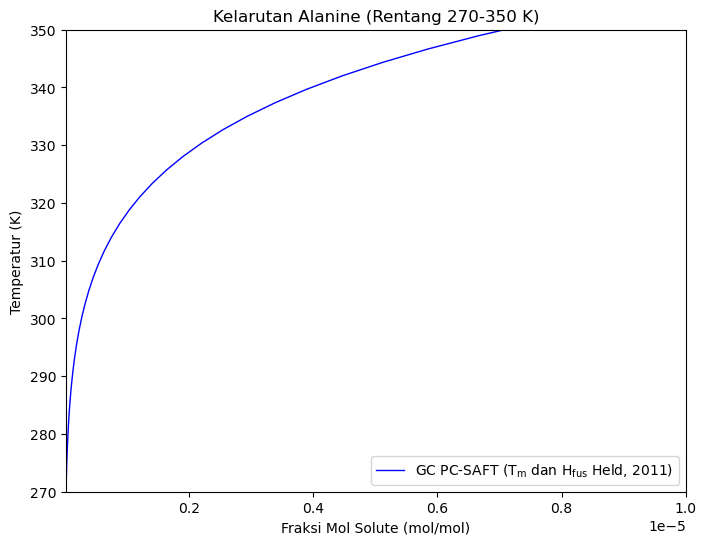

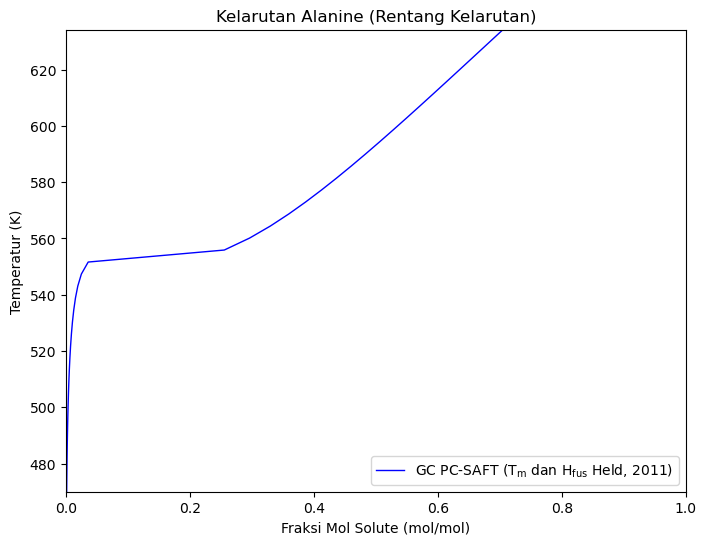

In [34]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_alanine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 500., 100)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["alanine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Alanine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(2e-8, 1e-5)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_T_alanine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model3.solid.params.Tm[2], 100)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["alanine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Alanine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(470.0, 634.138)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_x_alanine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [34]:
aard_p   = calculate_AAD(model3, "sol_alanine.csv", solubility_held)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.000000      99.9997 
293.1500    0.030824      0.000000      99.9995 
303.1500    0.034189      0.000000      99.9990 
313.1500    0.037970      0.000001      99.9981 
323.1500    0.042015      0.000001      99.9967 
AARD = 99.9986%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99861279791017

# 4
- pure comp: GC
- kij: molecular
- melting: GC

In [35]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter4 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
alanine_gclow,89.09,6.26356,2.463455,264.4748,2,2
alanine_gcmid,89.09,6.26356,2.463455,264.4748,2,2
alanine_gcup,89.09,6.26356,2.463455,264.4748,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter4 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,alanine_gclow,-0.0612
water,alanine_gcmid,-0.0612
water,alanine_gcup,-0.0612
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter4 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
alanine_gclow,H,alanine_gclow,e,3150.875718,0.102188
alanine_gcmid,H,alanine_gcmid,e,3150.875718,0.102188
alanine_gcup,H,alanine_gcup,e,3150.875718,0.102188
water,H,alanine_gclow,e,2788.273,0.067393
water,e,alanine_gclow,H,2788.273,0.067393
water,H,alanine_gcmid,e,2788.273,0.067393
water,e,alanine_gcmid,H,2788.273,0.067393
water,H,alanine_gcup,e,2788.273,0.067393
water,e,alanine_gcup,H,2788.273,0.067393
"""
components_low = ["water", "alanine_gclow"]
components_mid = ["water", "alanine_gcmid"]
components_up = ["water", "alanine_gcup"]

model4_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])


println("low bound")
println("Hfus = ", model4_low.solid.params.Hfus[2])
println("Tm = ", model4_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model4_mid.solid.params.Hfus[2])
println("Tm = ", model4_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model4_up.solid.params.Hfus[2])
println("Tm = ", model4_up.solid.params.Tm[2])

low bound
Hfus = 19111.8
Tm = 534.7097
mid bound
Hfus = 22861.0
Tm = 580.58
up bound
Hfus = 26610.2
Tm = 626.4406



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low     X_Mid      X_Up      
     │ Float64       Float64   Float64    Float64   
─────┼──────────────────────────────────────────────
   1 │      270.0    0.103828  0.0418516  0.0114695
   2 │      272.674  0.108206  0.0452048  0.0128311
   3 │      275.348  0.112599  0.048639   0.014312
   4 │      278.022  0.117009  0.0521446  0.0159157
   5 │      280.695  0.121438  0.0557131  0.0176446
   6 │      283.369  0.125887  0.0593372  0.0194998
   7 │      286.043  0.130359  0.0630108  0.0214813
   8 │      288.717  0.134854  0.066729   0.0235876
   9 │      291.391  0.139376  0.0704875  0.0258159
  10 │      294.065  0.143925  0.0742831  0.0281624
  11 │      296.738  0.148504  0.0781134  0.0306222
  12 │      299.412  0.153115  0.0819764  0.0331897
  13 │      302.086  0.157759  0.0858708  0.0358589
  14 │      304.76   0.162439  0.0897956  0.0386232
  15 │      307.434  0.167155  0.0937503  0.0414764
  16 │      3

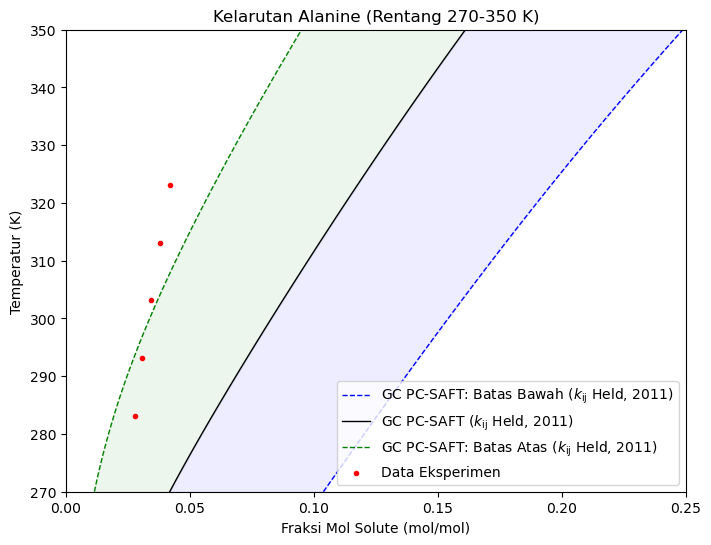

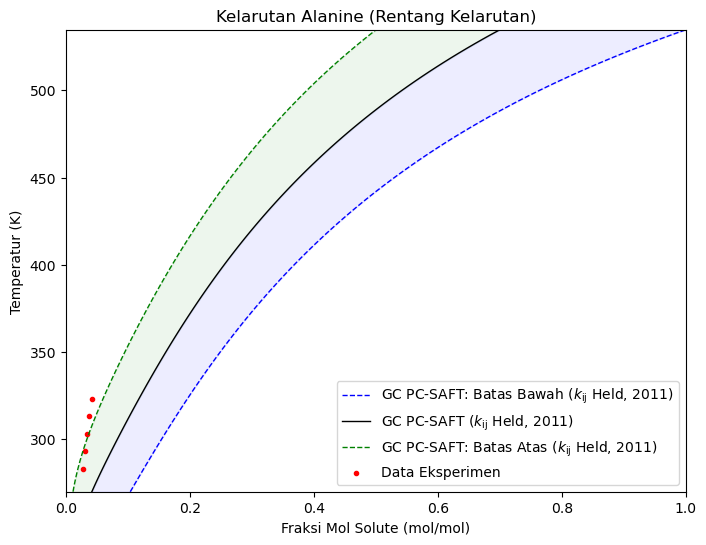

In [36]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_alanine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["alanine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["alanine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["alanine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Alanine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_T_alanine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model4_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["alanine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["alanine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["alanine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Alanine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, model4_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_x_alanine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [37]:
aard_p   = calculate_AAD(model4_low, "sol_alanine.csv", solubility_gclow)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.125522      350.3352
293.1500    0.030824      0.142366      361.8679
303.1500    0.034189      0.159617      366.8662


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


313.1500    0.037970      0.177372      367.1367
323.1500    0.042015      0.195728      365.8529
AARD = 362.4118%


362.41177959669494

In [38]:
aard_p   = calculate_AAD(model4_mid, "sol_alanine.csv", solubility_gcmid)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.059038      111.8114
293.1500    0.030824      0.072981      136.7665
303.1500    0.034189      0.087429      155.7225
313.1500    0.037970      0.102305      169.4354
323.1500    0.042015      0.117603      179.9072
AARD = 150.7286%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


150.7285943652355

In [39]:
aard_p   = calculate_AAD(model4_up, "sol_alanine.csv", solubility_gcup)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.019343      30.6031 
293.1500    0.030824      0.027347      11.2806 
303.1500    0.034189      0.036948      8.0693  
313.1500    0.037970      0.047845      26.0072 
323.1500    0.042015      0.059728      42.1576 
AARD = 23.6236%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


23.62357240097167

# 5
- pure comp: GC
- kij: 0
- melting: GC

In [37]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter5 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
alanine_gclow,89.09,6.26356,2.463455,264.4748,2,2
alanine_gcmid,89.09,6.26356,2.463455,264.4748,2,2
alanine_gcup,89.09,6.26356,2.463455,264.4748,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter5 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,alanine_gclow,0
water,alanine_gcmid,0
water,alanine_gcup,0
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter5 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
alanine_gclow,H,alanine_gclow,e,3150.875718,0.102188
alanine_gcmid,H,alanine_gcmid,e,3150.875718,0.102188
alanine_gcup,H,alanine_gcup,e,3150.875718,0.102188
water,H,alanine_gclow,e,2788.273,0.067393
water,e,alanine_gclow,H,2788.273,0.067393
water,H,alanine_gcmid,e,2788.273,0.067393
water,e,alanine_gcmid,H,2788.273,0.067393
water,H,alanine_gcup,e,2788.273,0.067393
water,e,alanine_gcup,H,2788.273,0.067393
"""
components_low = ["water", "alanine_gclow"]
components_mid = ["water", "alanine_gcmid"]
components_up = ["water", "alanine_gcup"]

model5_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])


println("low bound")
println("Hfus = ", model5_low.solid.params.Hfus[2])
println("Tm = ", model5_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model5_mid.solid.params.Hfus[2])
println("Tm = ", model5_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model5_up.solid.params.Hfus[2])
println("Tm = ", model5_up.solid.params.Tm[2])

low bound
Hfus = 19111.8
Tm = 534.7097
mid bound
Hfus = 22861.0
Tm = 580.58
up bound
Hfus = 26610.2
Tm = 626.4406



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low       X_Mid        X_Up        
     │ Float64       Float64     Float64      Float64     
─────┼────────────────────────────────────────────────────
   1 │      270.0    0.00142008  0.000395614  0.000106763
   2 │      272.674  0.00163194  0.000459577  0.000125852
   3 │      275.348  0.00187216  0.000532472  0.000147885
   4 │      278.022  0.00214438  0.000615373  0.000173246
   5 │      280.695  0.00245276  0.000709472  0.000202361
   6 │      283.369  0.00280212  0.00081609   0.000235699
   7 │      286.043  0.003198    0.000936693  0.000273781
   8 │      288.717  0.00364686  0.00107291   0.000317179
   9 │      291.391  0.0041563   0.00122656   0.000366527
  10 │      294.065  0.00473527  0.00139966   0.000422522
  11 │      296.738  0.00539442  0.00159446   0.000485932
  12 │      299.412  0.00614659  0.00181351   0.000557601
  13 │      302.086  0.00700732  0.00205963   0.000638461
  14 │      304.76  

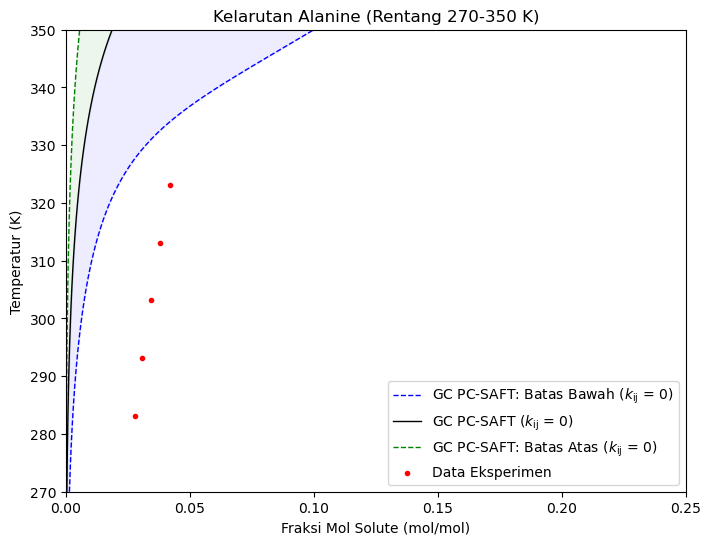

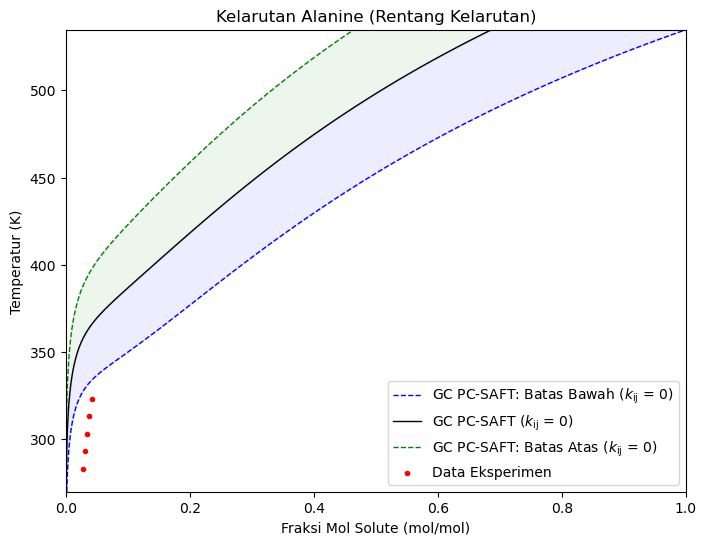

In [38]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_alanine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["alanine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["alanine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["alanine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Alanine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_T_alanine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model5_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["alanine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["alanine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["alanine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Alanine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, model5_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_x_alanine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [42]:
aard_p   = calculate_AAD(model5_low, "sol_alanine.csv", solubility_gclow)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.002772      90.0556 
293.1500    0.030824      0.004529      85.3076 
303.1500    0.034189      0.007384      78.4021 
313.1500    0.037970      0.012227      67.7988 
323.1500    0.042015      0.021147      49.6688 
AARD = 74.2465%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


74.24654929816828

In [43]:
aard_p   = calculate_AAD(model5_mid, "sol_alanine.csv", solubility_gcmid)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.000807      97.1053 
293.1500    0.030824      0.001338      95.6588 
303.1500    0.034189      0.002166      93.6652 
313.1500    0.037970      0.003443      90.9323 
323.1500    0.042015      0.005415      87.1126 
AARD = 92.8948%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


92.89483446785887

In [44]:
aard_p   = calculate_AAD(model5_up, "sol_alanine.csv", solubility_gcup)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.000233      99.1648 
293.1500    0.030824      0.000403      98.6940 
303.1500    0.034189      0.000673      98.0303 
313.1500    0.037970      0.001095      97.1165 
323.1500    0.042015      0.001738      95.8628 
AARD = 97.7737%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


97.77366338751509

# 6
- pure comp: GC
- kij: molecular (VLE GC)
- melting: GC

In [39]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter6 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
alanine_gclow,89.09,6.26356,2.463455,264.4748,2,2
alanine_gcmid,89.09,6.26356,2.463455,264.4748,2,2
alanine_gcup,89.09,6.26356,2.463455,264.4748,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter6 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,alanine_gclow,0.14645574
water,alanine_gcmid,0.14645574
water,alanine_gcup,0.14645574
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter6 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
alanine_gclow,H,alanine_gclow,e,3150.875718,0.102188
alanine_gcmid,H,alanine_gcmid,e,3150.875718,0.102188
alanine_gcup,H,alanine_gcup,e,3150.875718,0.102188
water,H,alanine_gclow,e,2788.273,0.067393
water,e,alanine_gclow,H,2788.273,0.067393
water,H,alanine_gcmid,e,2788.273,0.067393
water,e,alanine_gcmid,H,2788.273,0.0673937
water,H,alanine_gcup,e,2788.273,0.067393
water,e,alanine_gcup,H,2788.273,0.067393
"""
components_low = ["water", "alanine_gclow"]
components_mid = ["water", "alanine_gcmid"]
components_up = ["water", "alanine_gcup"]

model6_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])


println("low bound")
println("Hfus = ", model6_low.solid.params.Hfus[2])
println("Tm = ", model6_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model6_mid.solid.params.Hfus[2])
println("Tm = ", model6_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model6_up.solid.params.Hfus[2])
println("Tm = ", model6_up.solid.params.Tm[2])

low bound
Hfus = 19111.8
Tm = 534.7097
mid bound
Hfus = 22861.0
Tm = 580.58
up bound
Hfus = 26610.2
Tm = 626.4406



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    2.19538e-8   6.39748e-9   1.74876e-9
   2 │      272.674  2.83926e-8   8.41041e-9   2.33696e-9
   3 │      275.348  3.6534e-8    1.09972e-8   3.10521e-9
   4 │      278.022  4.67793e-8   1.43047e-8   4.10324e-9
   5 │      280.695  5.96126e-8   1.85128e-8   5.393e-9
   6 │      283.369  7.56158e-8   2.38413e-8   7.05133e-9
   7 │      286.043  9.54855e-8   3.05573e-8   9.17308e-9
   8 │      288.717  1.20052e-7   3.8984e-8    1.18748e-8
   9 │      291.391  1.50302e-7   4.95113e-8   1.52992e-8
  10 │      294.065  1.87403e-7   6.26073e-8   1.962e-8
  11 │      296.738  2.3273e-7    7.88319e-8   2.50482e-8
  12 │      299.412  2.87904e-7   9.88525e-8   3.18387e-8
  13 │      302.086  3.54817e-7   1.23462e-7   4.02985e-8
  14 │      304.76   

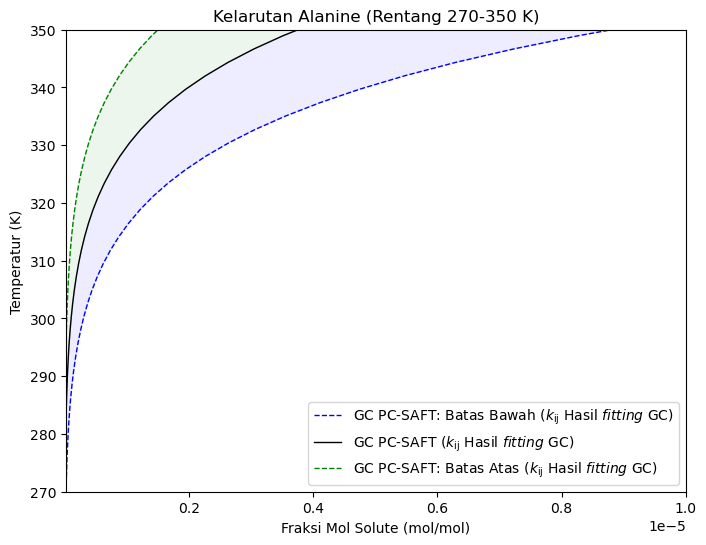

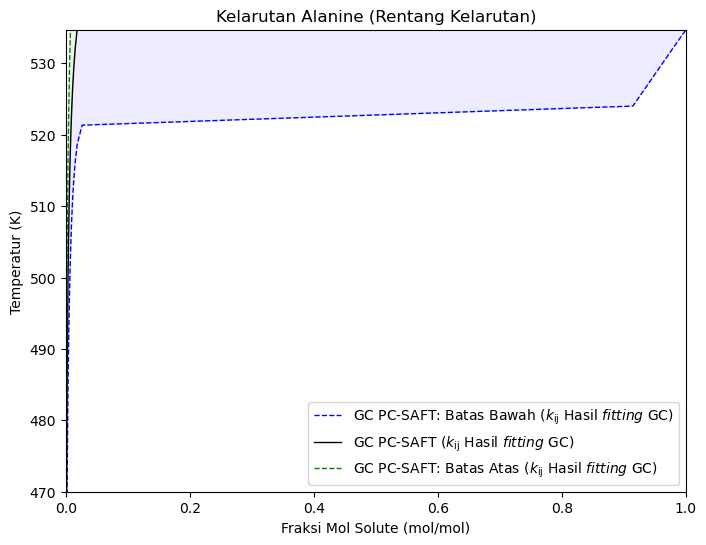

In [40]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_alanine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 500., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["alanine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["alanine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["alanine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Alanine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(2e-8, 1e-5)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_T_alanine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model6_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["alanine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["alanine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["alanine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Alanine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(470.0, model6_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_x_alanine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [47]:
aard_p   = calculate_AAD(model6_low, "sol_alanine.csv", solubility_gclow)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.000000      99.9997 


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


293.1500    0.030824      0.000000      99.9994 
303.1500    0.034189      0.000000      99.9989 
313.1500    0.037970      0.000001      99.9979 
323.1500    0.042015      0.000002      99.9961 
AARD = 99.9984%


99.998404485596

In [48]:
aard_p   = calculate_AAD(model6_mid, "sol_alanine.csv", solubility_gcmid)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.000000      99.9999 
293.1500    0.030824      0.000000      99.9998 
303.1500    0.034189      0.000000      99.9996 
313.1500    0.037970      0.000000      99.9992 
323.1500    0.042015      0.000001      99.9985 
AARD = 99.9994%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99941227319847

In [49]:
aard_p   = calculate_AAD(model6_up, "sol_alanine.csv", solubility_gcup)


=== AAD: sol_alanine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
283.1500    0.027873      0.000000      100.0000
293.1500    0.030824      0.000000      99.9999 
303.1500    0.034189      0.000000      99.9999 
313.1500    0.037970      0.000000      99.9997 
323.1500    0.042015      0.000000      99.9995 
AARD = 99.9998%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99979638911717